In [51]:
import matplotlib.pyplot as plt  # pyright: ignore[reportUnusedImport]
import pandas as pd  # pyright: ignore[reportUnusedImport]
import requests  # pyright: ignore[reportUnusedImport]
import zipfile  # pyright: ignore[reportUnusedImport]
from pathlib import Path  # pyright: ignore[reportUnusedImport]

from sklearn.compose import ColumnTransformer  # pyright: ignore[reportUnusedImport]
from sklearn.ensemble import RandomForestClassifier  # pyright: ignore[reportUnusedImport]
from sklearn.impute import SimpleImputer  # pyright: ignore[reportUnusedImport]
from sklearn.linear_model import LogisticRegression  # pyright: ignore[reportUnusedImport]
from sklearn.metrics import (  # pyright: ignore[reportUnusedImport]
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split  # pyright: ignore[reportUnusedImport]
from sklearn.pipeline import Pipeline  # pyright: ignore[reportUnusedImport]
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # pyright: ignore[reportUnusedImport]


RAW_DATA_DIR = Path("../data/raw")
CAR_PARKING_DATA_ZIP_URL = "https://opendatasoft-s3.s3.amazonaws.com/downloads/archive/t6hb-9uf2.zip"
PARKING_BAY_DATA_ZIP_URL = "https://opendatasoft-s3.s3.amazonaws.com/downloads/archive/mq3i-cbxd.zip"


def load_melbourne_api(dataset_slug, rows=5000):
    url = "https://data.melbourne.vic.gov.au/api/records/1.0/search/"

    params = {
        "dataset": dataset_slug,
        "rows": rows
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()
    records = data.get("records", [])

    return pd.DataFrame([record["fields"] for record in records])


def download_file(url, destination):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    with destination.open("wb") as output_file:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                output_file.write(chunk)

    return destination


def read_cached_zip_csv(zip_url, cache_name, nrows=None):
    cache_path = RAW_DATA_DIR / cache_name

    if not cache_path.exists():
        download_file(zip_url, cache_path)

    with zipfile.ZipFile(cache_path) as archive:
        csv_member = next(
            (name for name in archive.namelist() if name.lower().endswith(".csv")),
            None,
        )

        if csv_member is None:
            raise ValueError(f"No CSV file found inside {cache_path.name}")

        with archive.open(csv_member) as csv_file:
            return pd.read_csv(csv_file, nrows=nrows)


on_street_parking_bay_sensor_df = load_melbourne_api(
    "on-street-parking-bay-sensors",
    rows=5000
)

sign_plates_located_in_parking_bays_df = load_melbourne_api(
    "sign-plates-located-in-each-parking-zone",
    rows=5000
)

on_street_car_parking_sensor_df = read_cached_zip_csv(
    CAR_PARKING_DATA_ZIP_URL,
    "On-street_Car_Parking_Sensor_Data_-_2014.zip",
    nrows=300000,
)
parking_bay_arrivals_and_departures_df = read_cached_zip_csv(
    PARKING_BAY_DATA_ZIP_URL,
    "Parking_bay_arrivals_and_departures_2014.zip",
    nrows=300000,
)

/tmp/ipykernel_13129/3605339929.py:77: DtypeWarning: Columns (0: StreetId, 1: BetweenStreet1 Id, 2: BetweenStreet2 Id) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(csv_file, nrows=nrows)


In [52]:
print("**on_street_car_parking_sensor_df**")
print(on_street_car_parking_sensor_df.head())
print(on_street_car_parking_sensor_df.columns)
on_street_car_parking_sensor_df.info()

**on_street_car_parking_sensor_df**
  DeviceId             ArrivalTime           DepartureTime DurationSeconds  \
0   10,032  07/01/2014 11:43:23 AM  07/01/2014 11:43:30 AM               7   
1   11,649  03/19/2014 10:09:38 AM  03/19/2014 10:11:22 AM             104   
2    9,126  06/12/2014 07:30:00 AM  06/12/2014 10:17:23 AM          10,043   
3   12,462  07/02/2014 07:30:11 AM  07/02/2014 07:34:11 AM             240   
4   14,588  07/16/2014 08:12:00 AM  07/16/2014 08:12:14 AM              14   

  StreetMarker                       Sign            Area StreetId  \
0        3273S      1P MTR M-F 9:30-19:30          County      894   
1        2206N  1/2P MTR M-SAT 7:30-19:30        McKillop      911   
2       11921W      2P MTR M-F 7:30-18:30  East Melbourne      511   
3        2418N       1/4P M-SAT 7:30-9:30            RACV      123   
4       13749W  2P TKT A M-SAT 7:30-18:30       Docklands    1,398   

          StreetName   BetweenStreet1      BetweenStreet2  Side Of Street 

In [53]:
print("**on_street_parking_bay_sensor_df**")
print(on_street_parking_bay_sensor_df.head())
print(on_street_parking_bay_sensor_df.columns)
on_street_parking_bay_sensor_df.info()

**on_street_parking_bay_sensor_df**
            status_timestamp  zone_number                lastupdated  \
0  2025-04-14T03:01:40+00:00       7218.0  2025-05-08T05:44:34+00:00   
1  2024-03-06T20:13:57+00:00          NaN  2025-05-08T05:44:34+00:00   
2  2025-04-13T20:29:07+00:00       7219.0  2025-05-08T05:44:34+00:00   
3  2025-04-14T02:56:13+00:00       7219.0  2025-05-08T05:44:34+00:00   
4  2024-06-16T21:36:41+00:00       7081.0  2025-04-08T23:44:37+00:00   

   kerbsideid status_description                                   location  
0       57940         Unoccupied   [-37.82027020009988, 144.95458322910955]  
1       23372            Present  [-37.818697732486505, 144.95573756544826]  
2       69943            Present   [-37.82250487011976, 144.95216400545675]  
3       69946            Present   [-37.82253375737386, 144.95206800770742]  
4        8396         Unoccupied   [-37.80684173874762, 144.97325296739342]  
Index(['status_timestamp', 'zone_number', 'lastupdated', 'kerbs

In [54]:
print("**parking_bay_arrivals_and_departures_df**")
print(parking_bay_arrivals_and_departures_df.head())
print(parking_bay_arrivals_and_departures_df.columns)
parking_bay_arrivals_and_departures_df.info()

**parking_bay_arrivals_and_departures_df**
  ParkingEventId DeviceId                   ArrivalTime  \
0          3,123   11,710  04/02/2014 10:56:29 AM +0000   
1          3,124   11,710  04/02/2014 11:07:23 AM +0000   
2          3,125   11,710  04/02/2014 12:09:59 PM +0000   
3          3,126   11,710  04/02/2014 12:39:30 PM +0000   
4          3,129   11,710  04/02/2014 01:08:46 PM +0000   

                  DepartureTime DurationSeconds StreetMarker  SignPlateId  \
0  04/02/2014 11:06:08 AM +0000             600        6588N            6   
1  04/02/2014 11:38:48 AM +0000           1,860        6588N            6   
2  04/02/2014 12:34:30 PM +0000           1,500        6588N            6   
3  04/02/2014 12:58:07 PM +0000           1,140        6588N            6   
4  04/02/2014 01:14:46 PM +0000             360        6588N            6   

                      Sign  Area         AreaName  ...       StreetName  \
0  1P MTR M-SAT 7:30-19:30    12  Victoria Market  ...  FRANKLIN

In [55]:
print("**sign_plates_located_in_parking_bays_df**")
print(sign_plates_located_in_parking_bays_df.head())
print(sign_plates_located_in_parking_bays_df.columns)
sign_plates_located_in_parking_bays_df.info()

**sign_plates_located_in_parking_bays_df**
  restriction_display  parkingzone time_restrictions_start restriction_days  \
0                  2P         7003                07:30:00          Mon-Fri   
1                  1P         7009                07:30:00              Sat   
2                  1P         7056                07:30:00              Sat   
3                  2P         7066                07:30:00          Mon-Fri   
4                  2P         7062                07:30:00              Sat   

  time_restrictions_finish  
0                 18:30:00  
1                 12:30:00  
2                 12:30:00  
3                 18:30:00  
4                 12:30:00  
Index(['restriction_display', 'parkingzone', 'time_restrictions_start',
       'restriction_days', 'time_restrictions_finish'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2033 entries, 0 to 2032
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------  

In [56]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

on_street_car_parking_sensor_df = clean_column_names(on_street_car_parking_sensor_df)
on_street_parking_bay_sensor_df = clean_column_names(on_street_parking_bay_sensor_df)
parking_bay_arrivals_and_departures_df = clean_column_names(parking_bay_arrivals_and_departures_df)
sign_plates_located_in_parking_bays_df = clean_column_names(sign_plates_located_in_parking_bays_df)

In [57]:
print("on_street_car_parking_sensor_df columns:")
print(on_street_car_parking_sensor_df.columns.tolist())

print("\non_street_parking_bay_sensor_df columns:")
print(on_street_parking_bay_sensor_df.columns.tolist())

print("\nparking_bay_arrivals_and_departures_df columns:")
print(parking_bay_arrivals_and_departures_df.columns.tolist())

print("\nsign_plates_located_in_parking_bays_df columns:")
print(sign_plates_located_in_parking_bays_df.columns.tolist())

on_street_car_parking_sensor_df columns:
['deviceid', 'arrivaltime', 'departuretime', 'durationseconds', 'streetmarker', 'sign', 'area', 'streetid', 'streetname', 'betweenstreet1', 'betweenstreet2', 'side_of_street', 'in_violation', 'vehicle_present']

on_street_parking_bay_sensor_df columns:
['status_timestamp', 'zone_number', 'lastupdated', 'kerbsideid', 'status_description', 'location']

parking_bay_arrivals_and_departures_df columns:
['parkingeventid', 'deviceid', 'arrivaltime', 'departuretime', 'durationseconds', 'streetmarker', 'signplateid', 'sign', 'area', 'areaname', 'streetid', 'streetname', 'betweenstreet1_id', 'betweenstreet1_description', 'betweenstreet2_id', 'betweenstreet2_description', 'sideofstreet', 'sidecode', 'sidename', 'bayid', 'inviolation']

sign_plates_located_in_parking_bays_df columns:
['restriction_display', 'parkingzone', 'time_restrictions_start', 'restriction_days', 'time_restrictions_finish']


In [58]:
on_street_car_parking_sensor_df = on_street_car_parking_sensor_df.drop_duplicates()
on_street_parking_bay_sensor_df["location"] = (
    on_street_parking_bay_sensor_df["location"].apply(
        lambda value: tuple(value) if isinstance(value, list) else value
    )
)
on_street_parking_bay_sensor_df = on_street_parking_bay_sensor_df.drop_duplicates()
parking_bay_arrivals_and_departures_df = parking_bay_arrivals_and_departures_df.drop_duplicates()
sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.drop_duplicates()

In [59]:
# For 2014 sensor data
on_street_car_parking_sensor_df["deviceid"] = (
    on_street_car_parking_sensor_df["deviceid"].astype(str).str.replace(",", "", regex=False)
)
on_street_car_parking_sensor_df["streetid"] = (
    on_street_car_parking_sensor_df["streetid"].astype(str).str.replace(",", "", regex=False)
)
on_street_car_parking_sensor_df["durationseconds"] = (
    on_street_car_parking_sensor_df["durationseconds"].astype(str).str.replace(",", "", regex=False)
)

# For arrivals/departures data
parking_bay_arrivals_and_departures_df["parkingeventid"] = (
    parking_bay_arrivals_and_departures_df["parkingeventid"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["deviceid"] = (
    parking_bay_arrivals_and_departures_df["deviceid"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["durationseconds"] = (
    parking_bay_arrivals_and_departures_df["durationseconds"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["bayid"] = (
    parking_bay_arrivals_and_departures_df["bayid"].astype(str).str.replace(",", "", regex=False)
)

In [60]:
on_street_car_parking_sensor_df["deviceid"] = pd.to_numeric(on_street_car_parking_sensor_df["deviceid"], errors="coerce")
on_street_car_parking_sensor_df["streetid"] = pd.to_numeric(on_street_car_parking_sensor_df["streetid"], errors="coerce")
on_street_car_parking_sensor_df["durationseconds"] = pd.to_numeric(on_street_car_parking_sensor_df["durationseconds"], errors="coerce")

parking_bay_arrivals_and_departures_df["parkingeventid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["parkingeventid"], errors="coerce")
parking_bay_arrivals_and_departures_df["deviceid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["deviceid"], errors="coerce")
parking_bay_arrivals_and_departures_df["durationseconds"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["durationseconds"], errors="coerce")
parking_bay_arrivals_and_departures_df["bayid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["bayid"], errors="coerce")

In [61]:
on_street_car_parking_sensor_df["arrivaltime"] = pd.to_datetime(
    on_street_car_parking_sensor_df["arrivaltime"],
    errors="coerce"
)

on_street_car_parking_sensor_df["departuretime"] = pd.to_datetime(
    on_street_car_parking_sensor_df["departuretime"],
    errors="coerce"
)

on_street_parking_bay_sensor_df["lastupdated"] = pd.to_datetime(
    on_street_parking_bay_sensor_df["lastupdated"],
    errors="coerce",
    utc=True
)

on_street_parking_bay_sensor_df["status_timestamp"] = pd.to_datetime(
    on_street_parking_bay_sensor_df["status_timestamp"],
    errors="coerce",
    utc=True
)

parking_bay_arrivals_and_departures_df["arrivaltime"] = pd.to_datetime(
    parking_bay_arrivals_and_departures_df["arrivaltime"],
    errors="coerce"
)

parking_bay_arrivals_and_departures_df["departuretime"] = pd.to_datetime(
    parking_bay_arrivals_and_departures_df["departuretime"],
    errors="coerce"
)

In [62]:
on_street_car_parking_sensor_df = on_street_car_parking_sensor_df.dropna(
    subset=["deviceid", "arrivaltime", "departuretime"]
)

on_street_parking_bay_sensor_df = on_street_parking_bay_sensor_df.dropna(
    subset=["status_timestamp", "status_description", "kerbsideid"]
)

parking_bay_arrivals_and_departures_df = parking_bay_arrivals_and_departures_df.dropna(
    subset=["deviceid", "arrivaltime", "departuretime", "bayid"]
)

sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.dropna(
    subset=["parkingzone"]
)

In [63]:
# 2014 sensor data
on_street_car_parking_sensor_df["arrival_hour"] = on_street_car_parking_sensor_df["arrivaltime"].dt.hour
on_street_car_parking_sensor_df["arrival_day"] = on_street_car_parking_sensor_df["arrivaltime"].dt.day_name()
on_street_car_parking_sensor_df["arrival_month"] = on_street_car_parking_sensor_df["arrivaltime"].dt.month
on_street_car_parking_sensor_df["is_weekend"] = on_street_car_parking_sensor_df["arrivaltime"].dt.dayofweek >= 5

# Live bay sensor data
on_street_parking_bay_sensor_df["status_hour"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.hour
on_street_parking_bay_sensor_df["status_day"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.day_name()
on_street_parking_bay_sensor_df["status_month"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.month
on_street_parking_bay_sensor_df["is_weekend"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.dayofweek >= 5

# Arrivals/departures data
parking_bay_arrivals_and_departures_df["arrival_hour"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.hour
parking_bay_arrivals_and_departures_df["arrival_day"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.day_name()
parking_bay_arrivals_and_departures_df["arrival_month"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.month
parking_bay_arrivals_and_departures_df["is_weekend"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.dayofweek >= 5

In [64]:
# Keep timestamps timezone-naive so they are easier to read and export
on_street_parking_bay_sensor_df["lastupdated"] = (
    on_street_parking_bay_sensor_df["lastupdated"].dt.tz_convert(None)
)

on_street_parking_bay_sensor_df["status_timestamp"] = (
    on_street_parking_bay_sensor_df["status_timestamp"].dt.tz_convert(None)
)

In [65]:
on_street_parking_bay_sensor_df["occupied"] = on_street_parking_bay_sensor_df["status_description"].apply(
    lambda x: 1 if x == "Present" else 0
)

on_street_parking_bay_sensor_df["occupied"].value_counts()

occupied
1    1938
0    1371
Name: count, dtype: int64

In [66]:
sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.rename(
    columns={"parkingzone": "zone_number"}
)

sign_plates_located_in_parking_bays_df.head()

,restriction_display,zone_number,time_restrictions_start,restriction_days,time_restrictions_finish
0,2P,7003,07:30:00,Mon-Fri,18:30:00
1,1P,7009,07:30:00,Sat,12:30:00
2,1P,7056,07:30:00,Sat,12:30:00
3,2P,7066,07:30:00,Mon-Fri,18:30:00
4,2P,7062,07:30:00,Sat,12:30:00


In [67]:
merged_bay_df = on_street_parking_bay_sensor_df.merge(
    sign_plates_located_in_parking_bays_df,
    on="zone_number",
    how="left"
)

print("Merged shape:", merged_bay_df.shape)
display(merged_bay_df.head())

Merged shape: (7995, 15)


,status_timestamp,zone_number,lastupdated,kerbsideid,status_description,location,status_hour,status_day,status_month,is_weekend,occupied,restriction_display,time_restrictions_start,restriction_days,time_restrictions_finish
0,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,19:00:00,Mon-Fri,22:00:00
1,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,07:00:00,Sat-Sun,22:00:00
2,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,09:00:00,Mon-Fri,16:00:00
3,2024-03-06 20:13:57,NaN,2025-05-08 05:44:34,23372,Present,"(-37.818697732486505, 144.95573756544826)",20,Wednesday,3,False,1,NaN,NaN,NaN,NaN
4,2025-04-13 20:29:07,7219.0,2025-05-08 05:44:34,69943,Present,"(-37.82250487011976, 144.95216400545675)",20,Sunday,4,True,1,LZ30,07:00:00,Mon-Fri,16:00:00


In [68]:
merged_bay_df.info()
print("\nMissing values after merge:")
print(merged_bay_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7995 entries, 0 to 7994
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   status_timestamp          7995 non-null   datetime64[us]
 1   zone_number               7774 non-null   float64       
 2   lastupdated               7995 non-null   datetime64[us]
 3   kerbsideid                7995 non-null   int64         
 4   status_description        7995 non-null   str           
 5   location                  7995 non-null   object        
 6   status_hour               7995 non-null   int32         
 7   status_day                7995 non-null   str           
 8   status_month              7995 non-null   int32         
 9   is_weekend                7995 non-null   bool          
 10  occupied                  7995 non-null   int64         
 11  restriction_display       7729 non-null   str           
 12  time_restrictions_start   7729 

In [69]:
# We need zone_number for grouping, so remove rows where it is missing
merged_bay_df = merged_bay_df.dropna(subset=["zone_number"])

# Fill restriction details so downstream analysis has readable values
merged_bay_df["restriction_days"] = merged_bay_df["restriction_days"].fillna("Unknown")
merged_bay_df["restriction_display"] = merged_bay_df["restriction_display"].fillna("Unknown")
merged_bay_df["time_restrictions_start"] = merged_bay_df["time_restrictions_start"].fillna("Unknown")
merged_bay_df["time_restrictions_finish"] = merged_bay_df["time_restrictions_finish"].fillna("Unknown")

After merging the parking bay sensor data with the parking restriction data, some missing values were found. Rows with missing zone numbers were removed because zone information is necessary for grouping and demand analysis. Missing restriction-related fields were filled with "Unknown" so that the dataset remains usable and easier to interpret.

In [70]:
# Group occupancy by zone, day, hour, and weekend status
demand_df = (
    merged_bay_df.groupby(
        ["zone_number", "status_day", "status_hour", "is_weekend"],
        as_index=False
    )["occupied"].mean()
)

demand_df = demand_df.rename(columns={"occupied": "average_occupancy"})

display(demand_df.head())
print("Demand dataset shape:", demand_df.shape)

,zone_number,status_day,status_hour,is_weekend,average_occupancy
0,7010.0,Friday,1,False,0.0
1,7010.0,Thursday,21,False,1.0
2,7010.0,Thursday,22,False,1.0
3,7010.0,Thursday,23,False,1.0
4,7010.0,Wednesday,9,False,0.0


Demand dataset shape: (1506, 5)


In [71]:
def demand_level(value):
    if value < 0.33:
        return "Low"
    elif value < 0.66:
        return "Medium"
    else:
        return "High"

demand_df["demand_level"] = demand_df["average_occupancy"].apply(demand_level)

demand_df.head()

,zone_number,status_day,status_hour,is_weekend,average_occupancy,demand_level
0,7010.0,Friday,1,False,0.0,Low
1,7010.0,Thursday,21,False,1.0,High
2,7010.0,Thursday,22,False,1.0,High
3,7010.0,Thursday,23,False,1.0,High
4,7010.0,Wednesday,9,False,0.0,Low


In [72]:
print("Statistical summary of demand dataset:")
print(demand_df.describe())

Statistical summary of demand dataset:
       zone_number  status_hour  average_occupancy
count  1506.000000  1506.000000        1506.000000
mean   7462.959495     8.646082           0.548088
std     252.202100     6.802499           0.457922
min    7010.000000     0.000000           0.000000
25%    7239.000000     4.000000           0.000000
50%    7448.000000     7.000000           0.666667
75%    7640.000000    11.000000           1.000000
max    7995.000000    23.000000           1.000000


In [73]:
print("Missing values in cleaned demand_df:")
print(demand_df.isnull().sum())

Missing values in cleaned demand_df:
zone_number          0
status_day           0
status_hour          0
is_weekend           0
average_occupancy    0
demand_level         0
dtype: int64


In [74]:
# Save processed files
merged_bay_df.to_csv("../data/processed/merged_bay_sensor_data.csv", index=False)
demand_df.to_csv("../data/processed/cleaned_demand_data.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


## Exploratory Data Analysis

This section analyzes the cleaned parking datasets to identify hourly, daily, spatial, and restriction-based demand patterns that can support the predictive model.

In [75]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Merged dataset preview:")
display(merged_bay_df.head())
print("\nMerged dataset info:")
print(merged_bay_df.info())
print("\nMissing values in merged_bay_df:")
print(merged_bay_df.isnull().sum())

print("\nDemand dataset preview:")
display(demand_df.head())
print("\nDemand dataset info:")
print(demand_df.info())
print("\nMissing values in demand_df:")
print(demand_df.isnull().sum())

Merged dataset preview:


,status_timestamp,zone_number,lastupdated,kerbsideid,status_description,location,status_hour,status_day,status_month,is_weekend,occupied,restriction_display,time_restrictions_start,restriction_days,time_restrictions_finish
0,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,19:00:00,Mon-Fri,22:00:00
1,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,07:00:00,Sat-Sun,22:00:00
2,2025-04-14 03:01:40,7218.0,2025-05-08 05:44:34,57940,Unoccupied,"(-37.82027020009988, 144.95458322910955)",3,Monday,4,False,0,MP2P,09:00:00,Mon-Fri,16:00:00
4,2025-04-13 20:29:07,7219.0,2025-05-08 05:44:34,69943,Present,"(-37.82250487011976, 144.95216400545675)",20,Sunday,4,True,1,LZ30,07:00:00,Mon-Fri,16:00:00
5,2025-04-13 20:29:07,7219.0,2025-05-08 05:44:34,69943,Present,"(-37.82250487011976, 144.95216400545675)",20,Sunday,4,True,1,MP2P,16:00:00,Mon-Fri,19:00:00



Merged dataset info:
<class 'pandas.DataFrame'>
Index: 7774 entries, 0 to 7994
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   status_timestamp          7774 non-null   datetime64[us]
 1   zone_number               7774 non-null   float64       
 2   lastupdated               7774 non-null   datetime64[us]
 3   kerbsideid                7774 non-null   int64         
 4   status_description        7774 non-null   str           
 5   location                  7774 non-null   object        
 6   status_hour               7774 non-null   int32         
 7   status_day                7774 non-null   str           
 8   status_month              7774 non-null   int32         
 9   is_weekend                7774 non-null   bool          
 10  occupied                  7774 non-null   int64         
 11  restriction_display       7774 non-null   str           
 12  time_restricti

,zone_number,status_day,status_hour,is_weekend,average_occupancy,demand_level
0,7010.0,Friday,1,False,0.0,Low
1,7010.0,Thursday,21,False,1.0,High
2,7010.0,Thursday,22,False,1.0,High
3,7010.0,Thursday,23,False,1.0,High
4,7010.0,Wednesday,9,False,0.0,Low



Demand dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   zone_number        1506 non-null   float64
 1   status_day         1506 non-null   str    
 2   status_hour        1506 non-null   int32  
 3   is_weekend         1506 non-null   bool   
 4   average_occupancy  1506 non-null   float64
 5   demand_level       1506 non-null   str    
dtypes: bool(1), float64(2), int32(1), str(2)
memory usage: 54.5 KB
None

Missing values in demand_df:
zone_number          0
status_day           0
status_hour          0
is_weekend           0
average_occupancy    0
demand_level         0
dtype: int64


### 1. Average Parking Demand by Hour

,status_hour,average_occupancy
0,0,0.688774
1,1,0.575098
2,2,0.530375
3,3,0.529554
4,4,0.573871
5,5,0.622866
6,6,0.688252
7,7,0.596470
8,8,0.369504
9,9,0.372781


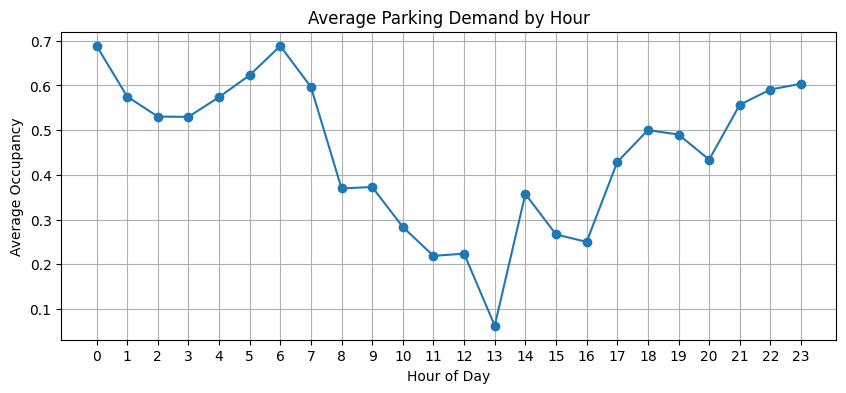

In [76]:
hourly_demand = demand_df.groupby("status_hour", as_index=False)["average_occupancy"].mean()
display(hourly_demand)

plt.figure(figsize=(10, 4))
plt.plot(hourly_demand["status_hour"], hourly_demand["average_occupancy"], marker="o")
plt.title("Average Parking Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### 2. Average Parking Demand by Day of the Week

,status_day,average_occupancy
1,Monday,0.537356
5,Tuesday,0.444155
6,Wednesday,0.526744
4,Thursday,0.425415
0,Friday,0.540994
2,Saturday,0.648850
3,Sunday,0.421111


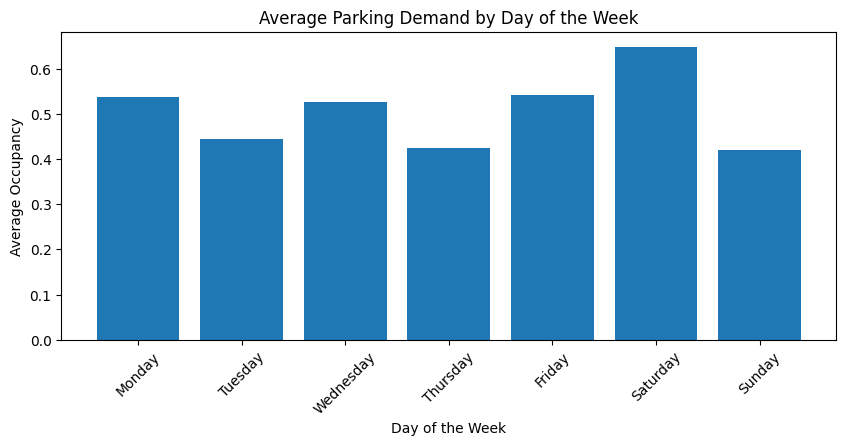

In [77]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_demand = demand_df.groupby("status_day", as_index=False)["average_occupancy"].mean()
daily_demand["status_day"] = pd.Categorical(daily_demand["status_day"], categories=day_order, ordered=True)
daily_demand = daily_demand.sort_values("status_day")
display(daily_demand)

plt.figure(figsize=(10, 4))
plt.bar(daily_demand["status_day"], daily_demand["average_occupancy"])
plt.title("Average Parking Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

### 3. Demand Level Distribution

demand_level
High      768
Low       578
Medium    160
Name: count, dtype: int64


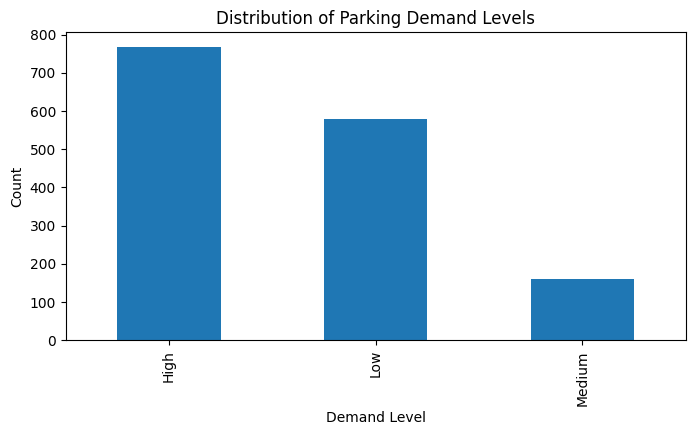

In [78]:
print(demand_df["demand_level"].value_counts())

plt.figure(figsize=(8, 4))
demand_df["demand_level"].value_counts().plot(kind="bar")
plt.title("Distribution of Parking Demand Levels")
plt.xlabel("Demand Level")
plt.ylabel("Count")
plt.show()

### 4. Zone-Based Parking Demand

,zone_number,average_occupancy,observation_count
2,7014.0,1.0,8
27,7185.0,1.0,3
32,7191.0,1.0,4
295,7740.0,1.0,10
293,7733.0,1.0,8
302,7764.0,1.0,12
303,7765.0,1.0,8
40,7205.0,1.0,1
49,7220.0,1.0,10
51,7223.0,1.0,8


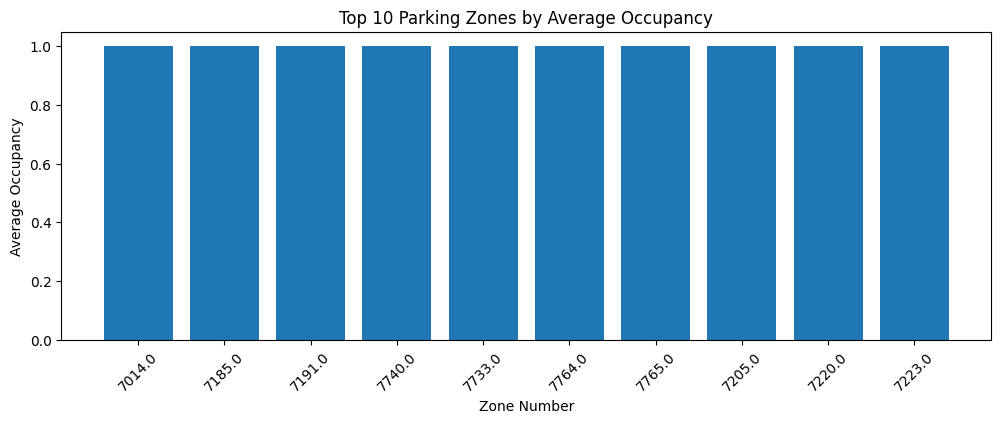

In [79]:
zone_summary = (
    merged_bay_df.groupby("zone_number")
    .agg(average_occupancy=("occupied", "mean"), observation_count=("occupied", "count"))
    .reset_index()
    .sort_values("average_occupancy", ascending=False)
)

display(zone_summary.head(10))

plt.figure(figsize=(12, 4))
plt.bar(zone_summary.head(10)["zone_number"].astype(str), zone_summary.head(10)["average_occupancy"])
plt.title("Top 10 Parking Zones by Average Occupancy")
plt.xlabel("Zone Number")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

### 5. Parking Restrictions and Weekend Patterns

,restriction_display,occupied
6,HP,1.000000
9,MP1P,0.833333
4,FP1P,0.823529
13,SP,0.681818
10,MP2P,0.631997
0,1P,0.631043
8,LZ30,0.625424
14,Unknown,0.577778
1,2P,0.546793
3,DP2P,0.545455


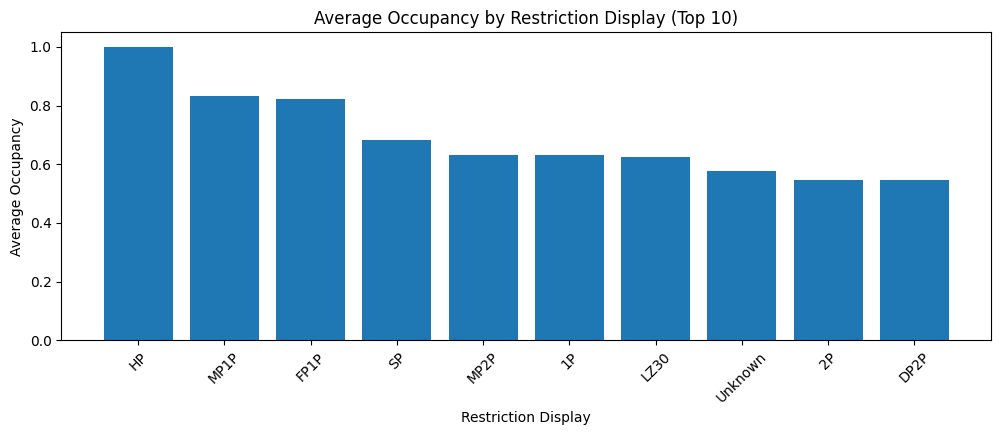

,is_weekend,occupied
0,False,0.535038
1,True,0.656099


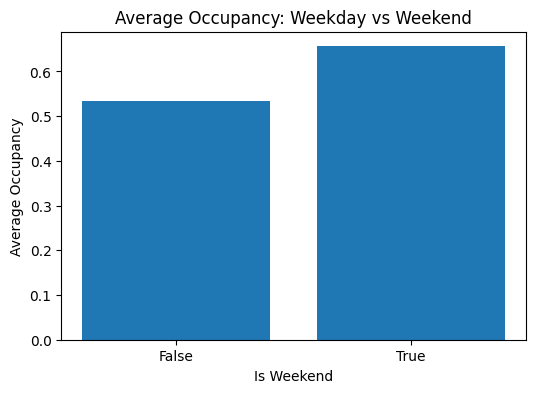

,status_hour,is_weekend,average_occupancy
0,0,False,0.657408
1,0,True,0.789474
2,1,False,0.537399
3,1,True,0.675000
4,2,False,0.468869


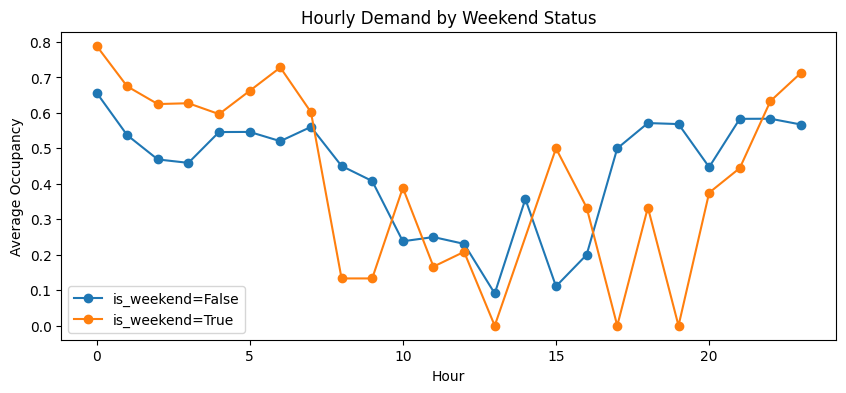

In [80]:
restriction_demand = (
    merged_bay_df.groupby("restriction_display", as_index=False)["occupied"]
    .mean()
    .sort_values("occupied", ascending=False)
)
weekend_comparison = merged_bay_df.groupby("is_weekend", as_index=False)["occupied"].mean()
hour_weekend_demand = demand_df.groupby(["status_hour", "is_weekend"], as_index=False)["average_occupancy"].mean()

display(restriction_demand.head(10))
plt.figure(figsize=(12, 4))
plt.bar(restriction_demand.head(10)["restriction_display"], restriction_demand.head(10)["occupied"])
plt.title("Average Occupancy by Restriction Display (Top 10)")
plt.xlabel("Restriction Display")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

display(weekend_comparison)
plt.figure(figsize=(6, 4))
plt.bar(weekend_comparison["is_weekend"].astype(str), weekend_comparison["occupied"])
plt.title("Average Occupancy: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("Average Occupancy")
plt.show()

display(hour_weekend_demand.head())
plt.figure(figsize=(10, 4))
for weekend_value in hour_weekend_demand["is_weekend"].unique():
    subset = hour_weekend_demand[hour_weekend_demand["is_weekend"] == weekend_value]
    plt.plot(subset["status_hour"], subset["average_occupancy"], marker="o", label=f"is_weekend={weekend_value}")
plt.legend()
plt.title("Hourly Demand by Weekend Status")
plt.xlabel("Hour")
plt.ylabel("Average Occupancy")
plt.show()

### 6. Statistical Summary

In [81]:
print("Statistical summary of demand dataset:")
print(demand_df.describe())
print("\nCorrelation summary:")
print(demand_df[["zone_number", "status_hour", "is_weekend", "average_occupancy"]].corr(numeric_only=True))

Statistical summary of demand dataset:
       zone_number  status_hour  average_occupancy
count  1506.000000  1506.000000        1506.000000
mean   7462.959495     8.646082           0.548088
std     252.202100     6.802499           0.457922
min    7010.000000     0.000000           0.000000
25%    7239.000000     4.000000           0.000000
50%    7448.000000     7.000000           0.666667
75%    7640.000000    11.000000           1.000000
max    7995.000000    23.000000           1.000000

Correlation summary:
                   zone_number  status_hour  is_weekend  average_occupancy
zone_number           1.000000    -0.073191    0.089123          -0.010304
status_hour          -0.073191     1.000000   -0.236734          -0.082712
is_weekend            0.089123    -0.236734    1.000000           0.125696
average_occupancy    -0.010304    -0.082712    0.125696           1.000000


## Machine Learning Model Development

The target variable is `demand_level`, which classifies parking demand as low, medium, or high. This section trains baseline and tree-based models using the engineered temporal and spatial features.

In [82]:
X = demand_df[["zone_number", "status_hour", "status_day", "is_weekend"]]
y = demand_df["demand_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Feature sample:")
display(X.head())
print("\nTarget sample:")
display(y.head())
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Feature sample:


,zone_number,status_hour,status_day,is_weekend
0,7010.0,1,Friday,False
1,7010.0,21,Thursday,False
2,7010.0,22,Thursday,False
3,7010.0,23,Thursday,False
4,7010.0,9,Wednesday,False



Target sample:


0     Low
1    High
2    High
3    High
4     Low
Name: demand_level, dtype: str


Training set size: (1204, 4)
Testing set size: (302, 4)


### 1. Feature Setup and Train-Test Split

In [83]:
numeric_features = ["zone_number", "status_hour"]
categorical_features = ["status_day", "is_weekend"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

### 2. Logistic Regression Baseline

Logistic Regression classification report:
              precision    recall  f1-score   support

        High       0.44      0.23      0.31       154
         Low       0.50      0.44      0.47       116
      Medium       0.08      0.28      0.12        32

    accuracy                           0.32       302
   macro avg       0.34      0.32      0.30       302
weighted avg       0.42      0.32      0.35       302



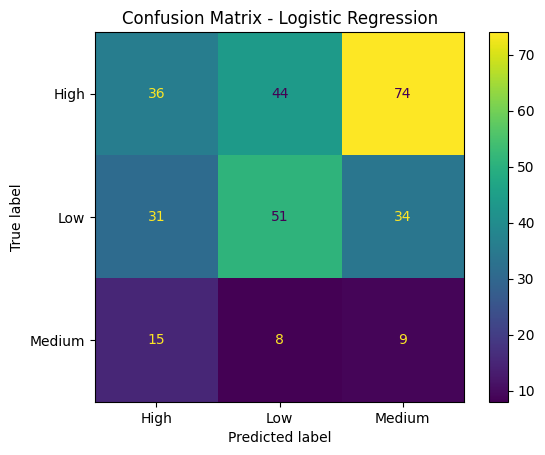

In [84]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, class_weight="balanced")),
])
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression classification report:")
print(classification_report(y_test, y_pred_logistic))

cm_logistic = confusion_matrix(y_test, y_pred_logistic, labels=logistic_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=logistic_model.classes_)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### 3. Random Forest Model

Random Forest classification report:
              precision    recall  f1-score   support

        High       0.62      0.58      0.60       154
         Low       0.51      0.47      0.49       116
      Medium       0.23      0.38      0.28        32

    accuracy                           0.51       302
   macro avg       0.45      0.47      0.46       302
weighted avg       0.54      0.51      0.52       302



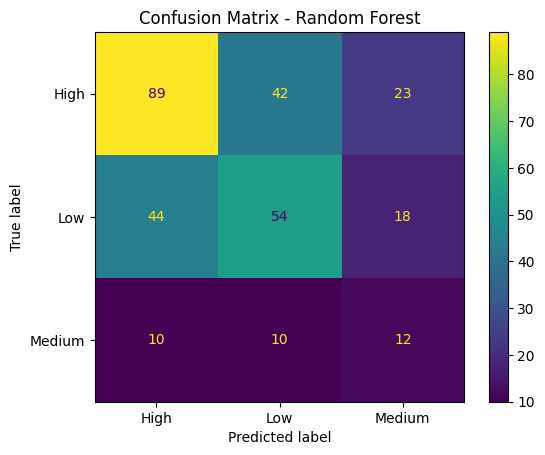

In [85]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
    )),
])
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=random_forest_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### 4. Model Comparison and Cross-Validation

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Logistic Regression,0.3179,0.3182,0.2972
1,Random Forest,0.5132,0.4728,0.4561


<Figure size 900x500 with 0 Axes>

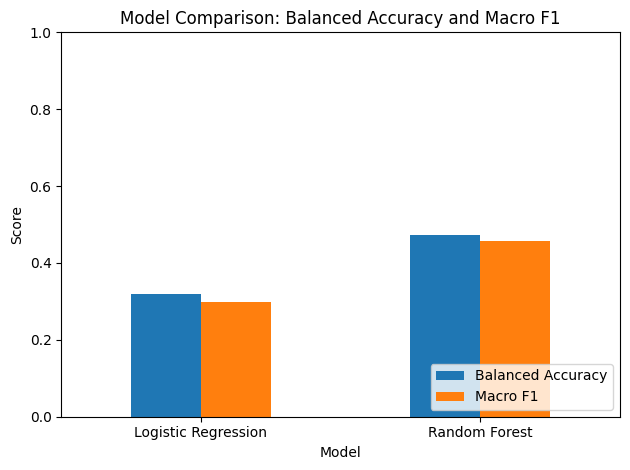

,Metric,Mean,Std
0,Accuracy,0.5478,0.0183
1,Balanced Accuracy,0.4699,0.0242
2,Macro F1,0.4655,0.0217


In [86]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_logistic), accuracy_score(y_test, y_pred_rf)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test, y_pred_logistic), balanced_accuracy_score(y_test, y_pred_rf)],
    "Macro F1": [f1_score(y_test, y_pred_logistic, average="macro"), f1_score(y_test, y_pred_rf, average="macro")],
})

display(comparison_df.round(4))

plot_df = comparison_df.set_index("Model")[["Balanced Accuracy", "Macro F1"]]
plt.figure(figsize=(9, 5))
plot_df.plot(kind="bar", ylim=(0, 1), rot=0)
plt.title("Model Comparison: Balanced Accuracy and Macro F1")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "Macro F1"],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_balanced_accuracy"].mean(),
        cv_scores["test_macro_f1"].mean(),
    ],
    "Std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_balanced_accuracy"].std(),
        cv_scores["test_macro_f1"].std(),
    ],
})

display(cv_summary.round(4))

### 5. Example Prediction

In [87]:
sample_input = pd.DataFrame({
    "zone_number": [7303],
    "status_hour": [10],
    "status_day": ["Monday"],
    "is_weekend": [False],
})
print("Example prediction:")
display(sample_input)
print("Logistic Regression Prediction:", logistic_model.predict(sample_input)[0])
print("Random Forest Prediction:", random_forest_model.predict(sample_input)[0])

Example prediction:


,zone_number,status_hour,status_day,is_weekend
0,7303,10,Monday,False


Logistic Regression Prediction: Medium
Random Forest Prediction: Low


The cleaned dataset now represents average parking occupancy by zone, day, hour, and weekend status. This makes it suitable for later exploratory data analysis and for building a model to classify parking demand as low, medium, or high.